In [1]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame

import cartopy.crs as ccrs
from cartopy.crs import Geodetic, PlateCarree
import cartopy

warnings.simplefilter('ignore')

In [2]:
# Plot relevant parameters
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
def basemap(ax, extent=extent):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=['left', 'bottom'], y_inline=False,)
    return ax

In [3]:
def make_sample_point(
        location_name, location_id, location_id_old, sample_kind, genomic_data, order, sea, location_lat, location_lon
        ):
        return {
                'location_name': location_name, 
                'location_id': location_id,
                'location_id_old': location_id_old,
                'sample_kind': sample_kind,
                'genomic_data': genomic_data,
                'order': order,
                'sea': sea,
                'geometry': gpd.points_from_xy([location_lon], [location_lat], crs=ccrs.Geodetic())[0],
        }

In [4]:
sample_point_list = [
        make_sample_point('KielBay03', 'KB03', 'KB03', 'real', True, 11, 'baltic', 54.692, 10.1035),
        make_sample_point('SW08', 'SW08', 'SW08', 'real', True, 13, 'baltic', 54.413, 11.617),
        make_sample_point('Boknis_Eck', 'BOK', 'BE01', 'real', True, 12, 'baltic', 54.5169, 10.034),
        make_sample_point('Gdynia', 'GDY', 'GD01', 'real', True, 19, 'baltic', 54.5829, 18.6042),
        make_sample_point('IU7_c', 'IU7', 'IU07', 'real', False, 28, 'baltic', 59.489, 21.2021),
        make_sample_point('LL17_c', 'LL17', 'LL17', 'real', False, 27, 'baltic', 59.02, 21.0478),
        make_sample_point('Finland', 'FIN', 'FI01', 'real', True, 29, 'baltic', 59.77, 23.2663),
        make_sample_point('Speicherkoog_moved', 'SK02', 'SK02', 'moved', True, 1, 'northsea', 54.11, 8.5),
        make_sample_point('Wilhelmshaven_moved', 'WH02', 'WH02', 'moved', True, 0, 'northsea', 53.637, 8.15),
        make_sample_point('Kategat01', 'KG01', 'KG01', 'digital', False, 10, 'northsea', 56.35, 11.8),
        make_sample_point('Kategat02', 'KG02', 'KG02', 'digital', False, 9, 'northsea', 57.0, 11.5),
        make_sample_point('Skagerak01', 'SR01', 'SR01', 'digital', False, 7, 'northsea', 58.0, 10.5),
        make_sample_point('Skagerak02', 'SR02', 'SR02', 'digital', False, 5, 'northsea', 57.5, 8.0),
        make_sample_point('JutlandBay', 'JB01', 'JB01', 'digital', False, 4, 'northsea', 56.5, 7.3),
        make_sample_point('DeutscheBucht01', 'DB01', 'DB01', 'digital', False, 3, 'northsea', 55.5, 7.25),
        make_sample_point('DeutscheBucht02', 'DB02', 'DB02', 'digital', False, 2, 'northsea', 54.6, 7.5),
        make_sample_point('BalticPropper01', 'BP01', 'BP01', 'digital', False, 17, 'baltic', 55.5, 17.2),
        make_sample_point('BalticPropper02', 'BP02', 'BP02', 'digital', False, 18, 'baltic', 56.1, 18.5),
        make_sample_point('EG01', 'EG01', 'EG01', 'digital', False, 24, 'baltic', 57.4, 20.2),
        make_sample_point('EG02', 'EG02', 'EG02', 'digital', False, 25, 'baltic', 58.3, 20.6),
        make_sample_point('Skagerak03', 'SR03', 'SR03', 'digital', False, 6, 'northsea', 58.3, 9.3),
        make_sample_point('WG01', 'WG01', 'WG01', 'digital', False, 21, 'baltic', 57.0, 17.4),
        make_sample_point('WG02', 'WG02', 'WG02', 'digital', False, 22, 'baltic', 58.5, 18.5),
        make_sample_point('BalticPropper03', 'BP03', 'BP03', 'digital', False, 20, 'baltic', 55.4, 19.3),
        make_sample_point('BB23', 'BB23', 'BB23', 'real', False, 15, 'baltic', 55.2912, 15.7503),
        make_sample_point('BB36', 'BB36', 'BB36', 'real', True, 16, 'baltic', 54.9589, 15.9981),
        make_sample_point('GB96', 'GB96', 'GB96', 'real', True, 23, 'baltic', 56.9165, 19.5827),
        make_sample_point('H21', 'H21', 'HR21', 'real', True, 14, 'baltic', 54.9433, 13.4914),
        make_sample_point('Speicherkoog', 'SK01', 'SK01', 'real', True, 1, 'northsea', 54.0929, 8.9487),
        make_sample_point('Wilhelmshaven', 'WH01', 'WH01', 'real', True, 0, 'northsea', 53.513, 8.149),
]

In [5]:
# Source - https://stackoverflow.com/a/5946359
# Posted by blubb, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

ds = sample_point_list
sample_points = {}
for column in sample_point_list[0].keys():
  sample_points[column] = list(location[column] for location in sample_point_list)
gdf_sample_points = GeoDataFrame(sample_points, crs=Geodetic()).sort_values('order')

In [6]:
# define paths
output_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/output/sample_points')

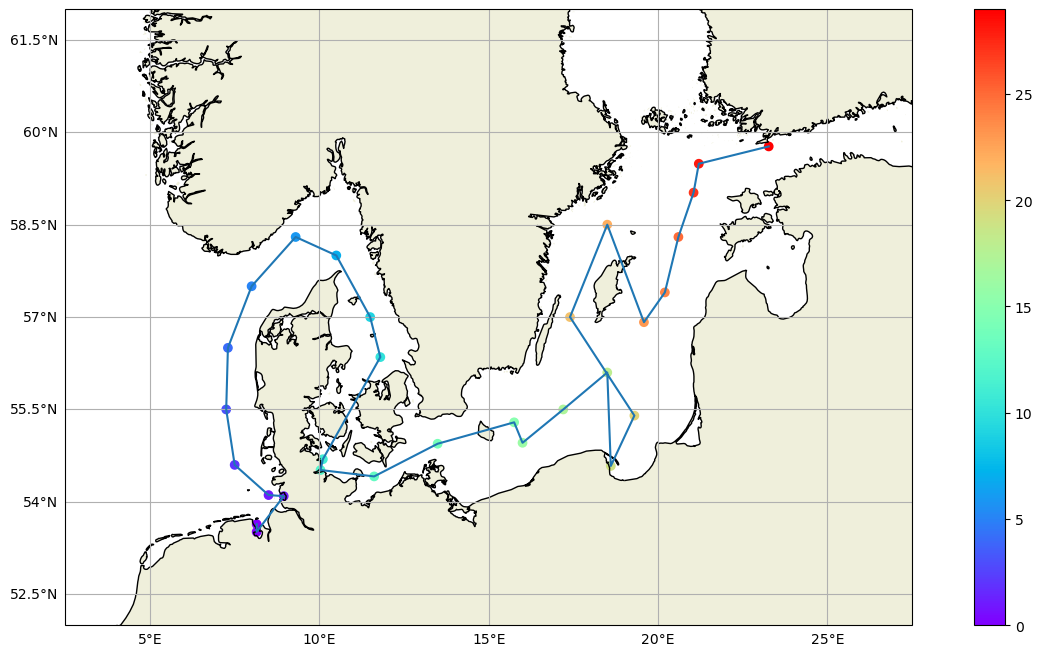

In [7]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=PlateCarree())
basemap(ax_map)
gdf_sample_points.plot(ax=ax_map, column='order', cmap='rainbow', legend=True)
ax_map.plot(gdf_sample_points.geometry.x, gdf_sample_points.geometry.y)
plt.show()

In [8]:
ocean_50m = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m')

for i, poly in enumerate(ocean_50m.intersecting_geometries(extent)):
    if i == 0:
        polygon = list([poly])
    else:
        polygon.append(poly)
sea_polygon = gpd.GeoDataFrame(geometry=polygon, crs=Geodetic())

In [9]:
def make_voronoi_polygons_from_sample_points(sample_points, sea_polygon):
    # Define the the radius of interest around the sample points
    centroid = sample_points.dissolve().centroid
    # # Set the central position of the Projection to the centroid
    crs_orthographic_centered = ccrs.Orthographic(
        central_longitude=centroid.x.values[0], 
        central_latitude=centroid.y.values[0]
        )
    sample_points = sample_points.to_crs(crs_orthographic_centered)
    area_of_interest = sample_points.set_geometry(sample_points.buffer(distance=1.25e5)).dissolve() # Dissolve the polygons to one single polygon

    # Build geodataframe for voronoi polygons
    voronoi_polygons = gpd.GeoDataFrame(geometry=sample_points.voronoi_polygons().clip(area_of_interest))
    voronoi_polygons = gpd.sjoin(
        left_df=sample_points, 
        right_df=voronoi_polygons, 
        how="right"
    ).set_index('index_left').sort_index().reset_index(drop=True)

    sea_polygon = sea_polygon.clip(area_of_interest.to_crs(Geodetic()))
    voronoi_polygons['sea_surface_area'] = (
        voronoi_polygons
        .clip(sea_polygon.to_crs(crs_orthographic_centered))
        .area/1e6 # devide by 10^6 because the unit we need is km^2 while th output unit is m^2
    )
    return voronoi_polygons.to_crs(Geodetic())#.sort_index()

In [10]:
sample_points_all = gdf_sample_points.set_index('order').reset_index(drop=True)
sample_points = gdf_sample_points.drop([29, 7]).set_index('order').reset_index(drop=True)
sample_points_original = gdf_sample_points.drop([8, 7]).set_index('order').reset_index(drop=True)
sample_points_moved = gdf_sample_points.drop([28, 29]).set_index('order').reset_index(drop=True)

In [11]:
voronoi_polygons_moved = make_voronoi_polygons_from_sample_points(sample_points_moved, sea_polygon)
voronoi_polygons_original = make_voronoi_polygons_from_sample_points(sample_points_original, sea_polygon)
voronoi_polygons = make_voronoi_polygons_from_sample_points(sample_points, sea_polygon)

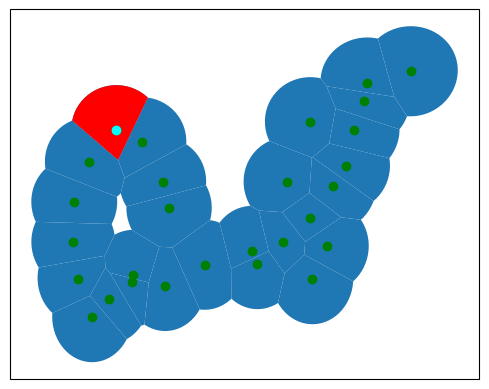

In [12]:
locid = 'SR03'
fig = plt.figure()
ax_map = fig.add_subplot(projection=PlateCarree())
voronoi_polygons.plot(ax=ax_map)
voronoi_polygons[voronoi_polygons.location_id.isin([locid])].plot(ax=ax_map, color='r')
sample_points.plot(ax=ax_map, color='g')
sample_points[sample_points.location_id.isin([locid])].plot(ax=ax_map, color='cyan')
plt.show()

In [13]:
sample_points['sea_surface_area'] = voronoi_polygons.sea_surface_area
sample_points_moved['sea_surface_area'] = voronoi_polygons_moved.sea_surface_area
sample_points_original['sea_surface_area'] = voronoi_polygons_original.sea_surface_area

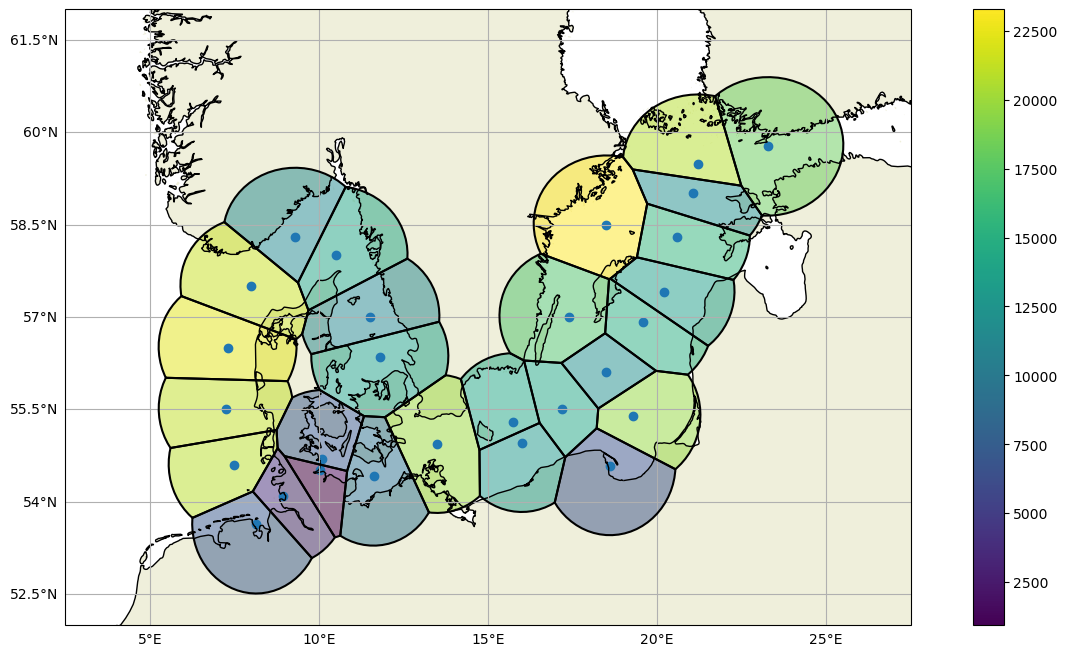

In [14]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=PlateCarree())
basemap(ax_map)
# basemap(ax_map, (7, 11, 53, 56))
voronoi_polygons.plot(ax=ax_map, alpha=0.5, column='sea_surface_area', legend=True)
voronoi_polygons.boundary.plot(ax=ax_map, color='k',)
sample_points.plot(ax=ax_map)
plt.show()

In [15]:
sample_points.to_file(output_path/'sample_points.geojson', driver='GeoJSON')
sample_points_all.to_file(output_path/'sample_points_all.geojson', driver='GeoJSON')
sample_points_original.to_file(output_path/'sample_points_original.geojson', driver='GeoJSON')
sample_points_moved.to_file(output_path/'sample_points_moved.geojson', driver='GeoJSON')
voronoi_polygons.to_file(output_path/'voronoi_polygons.geojson', driver='GeoJSON')
voronoi_polygons_original.to_file(output_path/'voronoi_polygons_original.geojson', driver='GeoJSON')
voronoi_polygons_moved.to_file(output_path/'voronoi_polygons_moved.geojson', driver='GeoJSON')